# Week 4 Analysis

Compare arm A (LSP + compiler) vs. arm B (compiler-only) across models.
Tests H1(a/b): arm A faster, fewer compiler calls.
Tests H2: partial scaling law — compiler calls drop with size, wall-clock may not.

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from soundcode.eval.analyze_week4 import (
    load_summary, per_model_arm_summary, hypothesis_h1,
    profile_breakdown, rollback_overhead_distribution, MODEL_PARAMS_B,
)

df = load_summary()
print(f'Problems loaded: {len(df)} rows across {df["model"].nunique()} models, {df["arm"].nunique()} arms')
df.head()

Problems loaded: 700 rows across 16 models, 2 arms


,model,arm,params_b,problem,compiled,passed,wall_s,to_compile_s,attempts,rollbacks,compiler_calls,tokens,discarded,timed_out,error_codes
0,deepseek-r1:70b,A,70.0,HumanEval_0_has_close_elements,True,True,21.276894,21.276892,1,0,1,61,0,False,[]
1,deepseek-r1:70b,A,70.0,HumanEval_1_separate_paren_groups,True,True,7.618939,7.618937,1,0,1,90,0,False,[]
2,deepseek-r1:70b,A,70.0,HumanEval_2_truncate_number,True,True,0.700946,0.700944,1,0,1,5,0,False,[]
3,deepseek-r1:70b,A,70.0,HumanEval_3_below_zero,True,True,2.796723,2.796721,1,0,1,28,0,False,[]
4,deepseek-r1:70b,A,70.0,HumanEval_4_mean_absolute_deviation,True,True,26.295994,26.295992,3,2,3,356,465,False,"[E0382, E0282]"


## Per-model, per-arm summary

In [2]:
summary = per_model_arm_summary(df)
summary

,model,arm,n,compile_rate,pass_rate,timeout_rate,median_wall_s,median_compile_s,avg_rollbacks,avg_compiler_calls,avg_tokens,avg_discarded
0,deepseek-r1:70b,A,20,0.950000,0.750000,0.050000,7.470096,7.321252,0.250000,1.200000,150.300000,180.150000
1,deepseek-r1:70b,B,20,0.750000,0.600000,0.250000,6.167033,4.653893,0.350000,1.100000,262.900000,285.000000
2,devstral-2:latest,A,20,0.650000,0.650000,0.350000,45.989821,30.583407,0.200000,0.850000,156.500000,390.200000
3,devstral-2:latest,B,20,0.600000,0.550000,0.400000,42.929285,27.499424,0.100000,0.700000,56.150000,21.050000
4,devstral-small-2:latest,A,20,0.950000,0.850000,0.050000,0.826675,0.797468,0.350000,1.300000,341.150000,767.400000
5,devstral-small-2:latest,B,20,0.850000,0.800000,0.150000,0.833455,0.772840,0.850000,1.700000,798.150000,1844.850000
6,gemma3:27b,A,20,0.900000,0.850000,0.100000,1.453810,1.380578,0.600000,1.500000,420.150000,1078.700000
7,gemma3:27b,B,20,0.900000,0.850000,0.100000,1.424370,1.336474,0.850000,1.750000,423.700000,1000.600000
8,gpt-oss:120b,A,20,0.950000,0.550000,0.050000,0.747835,0.675286,1.700000,2.650000,618.200000,2744.400000
9,gpt-oss:120b,B,20,1.000000,0.650000,0.000000,0.610156,0.610155,1.100000,2.100000,377.500000,1438.850000


## H1 paired comparison (problems compiled by both arms)

Reports: median wall-clock to first-pass-compile, median compiler calls,
fraction of paired problems where arm A wins, Wilcoxon signed-rank p-value.

In [3]:
h1 = hypothesis_h1(df)
h1

,model,n_paired,median_wall_A,median_wall_B,median_calls_A,median_calls_B,A_faster_frac,A_fewer_calls_frac,wilcoxon_p_wall,wilcoxon_p_calls
0,deepseek-r1:70b,15,4.675897,4.653893,1.0,1.0,0.266667,0.000000,0.229309,0.317311
1,devstral-2:latest,12,28.842847,27.499424,1.0,1.0,0.416667,0.000000,0.380371,NaN
2,devstral-small-2:latest,17,0.855878,0.772840,1.0,1.0,0.352941,0.000000,0.306046,NaN
3,gemma3:27b,18,1.380578,1.336474,1.0,1.0,0.333333,0.000000,0.073685,NaN
4,gpt-oss:120b,19,0.675286,0.616426,1.0,1.0,0.368421,0.105263,0.418041,0.892738
5,gpt-oss:20b,19,0.787164,0.478519,1.0,1.0,0.210526,0.105263,0.014069,0.785495
6,mistral-small3.2:24b,17,0.793589,0.713559,1.0,1.0,0.352941,0.058824,0.487381,0.317311
7,nemotron-3-nano:4b,14,0.622348,0.313954,1.0,1.0,0.071429,0.000000,0.000610,NaN
8,nemotron-3-super:120b,18,0.899312,0.863604,1.0,1.0,0.333333,0.000000,0.048279,NaN
9,nemotron-cascade-2:30b,18,0.784317,0.471721,1.0,1.0,0.222222,0.000000,0.002335,NaN


## H2: scaling correlations (Spearman)

In [4]:
from soundcode.eval.analyze_week4 import hypothesis_h2
h2 = hypothesis_h2(df)
for k, v in h2.items():
    print(f'  {k}: {v:+.3f}')

  rho_params_vs_compiler_calls_arm_A: -0.608
  p_params_vs_compiler_calls_arm_A: +0.012
  rho_params_vs_wall_arm_A: +0.513
  p_params_vs_wall_arm_A: +0.042
  rho_params_vs_compiler_calls_arm_B: -0.682
  p_params_vs_compiler_calls_arm_B: +0.004
  rho_params_vs_wall_arm_B: +0.681
  p_params_vs_wall_arm_B: +0.004


## Compile rate per model, by arm

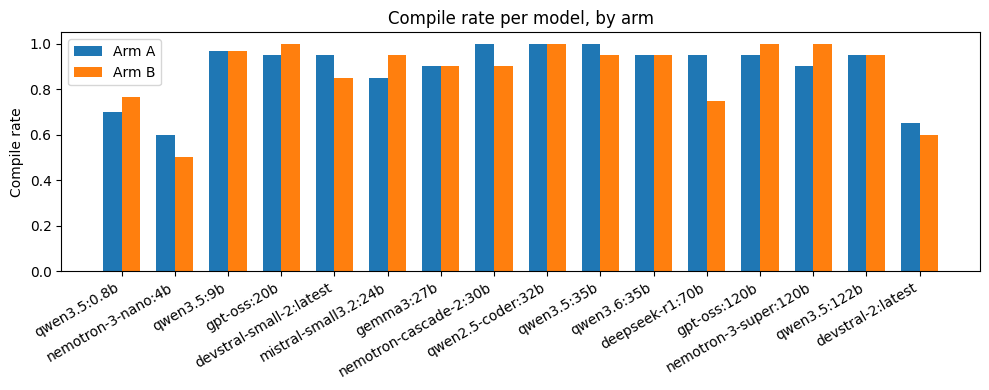

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
models = sorted(summary['model'].unique(), key=lambda m: MODEL_PARAMS_B.get(m, 1e9))
x = np.arange(len(models))
w = 0.35
for i, arm in enumerate(['A', 'B']):
    rates = [summary[(summary['model']==m) & (summary['arm']==arm)]['compile_rate'].iloc[0]
             if len(summary[(summary['model']==m) & (summary['arm']==arm)]) else 0
             for m in models]
    ax.bar(x + (i - 0.5) * w, rates, w, label=f'Arm {arm}')
ax.set_xticks(x); ax.set_xticklabels(models, rotation=30, ha='right')
ax.set_ylabel('Compile rate'); ax.set_title('Compile rate per model, by arm')
ax.legend(); plt.tight_layout(); plt.show()

## H2: scaling behaviour

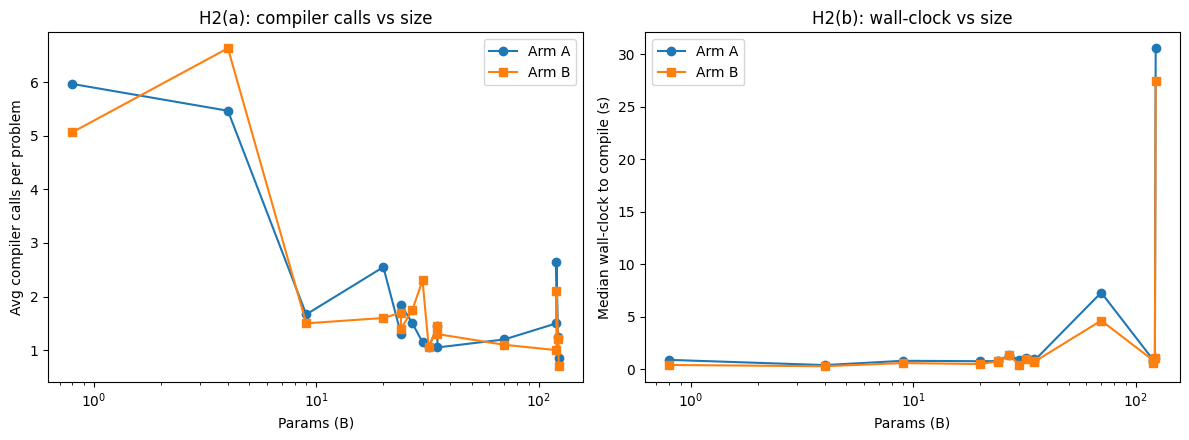

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
for arm, marker in [('A', 'o'), ('B', 's')]:
    sub = summary[summary['arm']==arm].copy()
    sub['params'] = sub['model'].map(MODEL_PARAMS_B)
    sub = sub.sort_values('params')
    ax1.plot(sub['params'], sub['avg_compiler_calls'], marker=marker, label=f'Arm {arm}')
    ax2.plot(sub['params'], sub['median_compile_s'], marker=marker, label=f'Arm {arm}')
ax1.set_xscale('log'); ax1.set_xlabel('Params (B)'); ax1.set_ylabel('Avg compiler calls per problem')
ax1.set_title('H2(a): compiler calls vs size'); ax1.legend()
ax2.set_xscale('log'); ax2.set_xlabel('Params (B)'); ax2.set_ylabel('Median wall-clock to compile (s)')
ax2.set_title('H2(b): wall-clock vs size'); ax2.legend()
plt.tight_layout(); plt.show()

## Profile breakdown

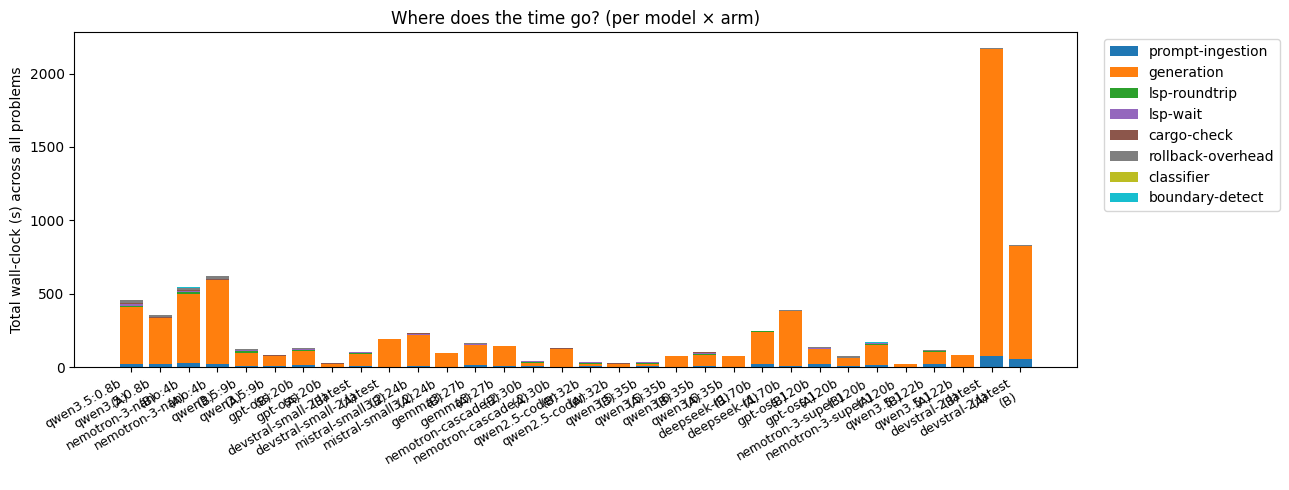

In [7]:
categories = ['prompt-ingestion', 'generation', 'lsp-roundtrip', 'lsp-wait',
              'cargo-check', 'rollback-overhead', 'classifier', 'boundary-detect']
fig, ax = plt.subplots(figsize=(13, 5))
colors = plt.cm.tab10(np.linspace(0, 1, len(categories)))
labels, stacks = [], {c: [] for c in categories}
for model in models:
    for arm in ('A', 'B'):
        bd = profile_breakdown(model, arm)
        if sum(bd.values()) == 0: continue
        labels.append(f'{model}\n({arm})')
        for c in categories:
            stacks[c].append(bd.get(c, 0))
x = np.arange(len(labels))
bottom = np.zeros(len(labels))
for c, color in zip(categories, colors):
    ax.bar(x, stacks[c], label=c, bottom=bottom, color=color)
    bottom += np.array(stacks[c])
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Total wall-clock (s) across all problems')
ax.set_title('Where does the time go? (per model × arm)')
ax.legend(bbox_to_anchor=(1.02, 1.0), loc='upper left')
plt.tight_layout(); plt.show()

## Rollback overhead distribution (arm A)

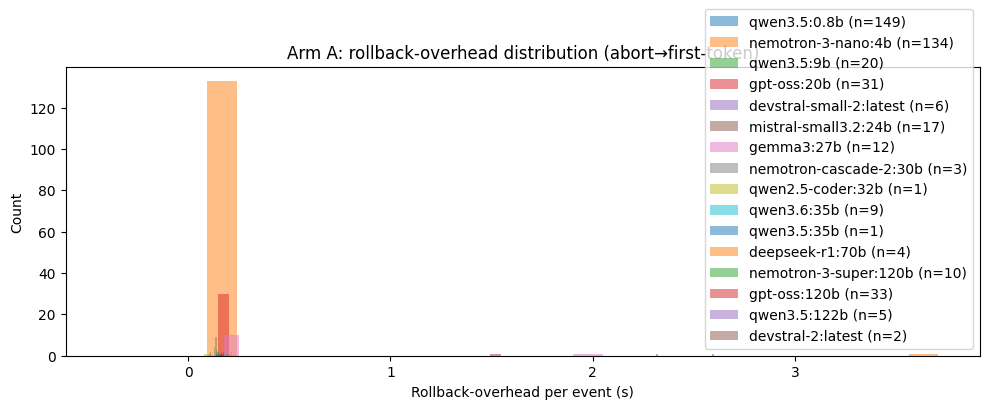

Per-model median:
  qwen3.5:0.8b: 0.14s (n=149)
  nemotron-3-nano:4b: 0.10s (n=134)
  qwen3.5:9b: 0.15s (n=20)
  gpt-oss:20b: 0.16s (n=31)
  devstral-small-2:latest: 0.11s (n=6)
  mistral-small3.2:24b: 0.11s (n=17)
  gemma3:27b: 0.20s (n=12)
  nemotron-cascade-2:30b: 0.12s (n=3)
  qwen2.5-coder:32b: 0.10s (n=1)
  qwen3.6:35b: 0.18s (n=9)
  qwen3.5:35b: 0.16s (n=1)
  deepseek-r1:70b: 0.21s (n=4)
  nemotron-3-super:120b: 0.18s (n=10)
  gpt-oss:120b: 0.17s (n=33)
  qwen3.5:122b: 0.23s (n=5)
  devstral-2:latest: 2.46s (n=2)


In [8]:
by_model = rollback_overhead_distribution()
fig, ax = plt.subplots(figsize=(10, 4))
for model, vals in sorted(by_model.items(), key=lambda kv: MODEL_PARAMS_B.get(kv[0], 1e9)):
    if vals:
        ax.hist(vals, bins=25, alpha=0.5, label=f'{model} (n={len(vals)})')
ax.set_xlabel('Rollback-overhead per event (s)'); ax.set_ylabel('Count')
ax.set_title('Arm A: rollback-overhead distribution (abort→first-token)')
ax.legend(); plt.tight_layout(); plt.show()
print('Per-model median:')
for model, vals in sorted(by_model.items(), key=lambda kv: MODEL_PARAMS_B.get(kv[0], 1e9)):
    if vals: print(f'  {model}: {np.median(vals):.2f}s (n={len(vals)})')

## Error-code distribution

In [9]:
from collections import Counter
for arm in ('A', 'B'):
    print(f'=== Arm {arm} ===')
    for model in models:
        codes = Counter()
        sub = df[(df['model'] == model) & (df['arm'] == arm)]
        for lst in sub['error_codes']:
            codes.update(lst)
        if codes:
            top = ', '.join(f'{c}={n}' for c, n in codes.most_common(6))
            print(f'  {model}: {top}')
        else:
            print(f'  {model}: (no codes)')

=== Arm A ===
  qwen3.5:0.8b: E0308=114, E0277=19, =11, E0433=4, E0425=3, E0599=3
  nemotron-3-nano:4b: E0308=134, E0277=5, E0412=2, =2, E0425=1, E0507=1
  qwen3.5:9b: =10, E0308=7, E0425=1, E0369=1, E0716=1, E0765=1
  gpt-oss:20b: =21, E0425=6, E0308=4, E0433=1
  devstral-small-2:latest: E0308=6, E0425=1
  mistral-small3.2:24b: E0308=18, E0425=1, E0282=1
  gemma3:27b: E0425=6, E0308=5, =1
  nemotron-cascade-2:30b: =2, E0277=1
  qwen2.5-coder:32b: E0412=1
  qwen3.5:35b: E0425=1
  qwen3.6:35b: E0308=7, E0425=2, =1
  deepseek-r1:70b: E0382=1, E0282=1, E0505=1, E0277=1, E0308=1
  gpt-oss:120b: =25, E0308=6, E0433=3
  nemotron-3-super:120b: E0308=10, E0425=1, E0412=1
  qwen3.5:122b: E0308=5, E0425=1
  devstral-2:latest: E0308=2, E0382=1, E0282=1
=== Arm B ===
  qwen3.5:0.8b: E0308=94, E0277=17, =7, E0599=4, E0425=3, E0384=2
  nemotron-3-nano:4b: E0308=163, E0433=6, E0277=5, E0425=2, =2, E0599=2
  qwen3.5:9b: E0308=7, =5, E0425=4
  gpt-oss:20b: =9, E0433=2, E0425=1
  devstral-small-2:latest

## Discard ratio (tokens thrown away by rollback)

In [10]:
from soundcode.eval.analyze_week4 import discarded_tokens_ratio
dr = discarded_tokens_ratio(df)
dr

,model,arm,tokens,discarded,discard_ratio
0,deepseek-r1:70b,A,3006,3603,1.198603
1,deepseek-r1:70b,B,5258,5700,1.084062
2,devstral-2:latest,A,3130,7804,2.493291
3,devstral-2:latest,B,1123,421,0.374889
4,devstral-small-2:latest,A,6823,15348,2.249450
5,devstral-small-2:latest,B,15963,36897,2.311408
6,gemma3:27b,A,8403,21574,2.567416
7,gemma3:27b,B,8474,20012,2.361577
8,gpt-oss:120b,A,12364,54888,4.439340
9,gpt-oss:120b,B,7550,28777,3.811523


## Per-problem wall-clock distribution

Boxplot per (model, arm). The tails show budget-cap failures (40s cap).

/tmp/ipykernel_1365020/3720852063.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels_order, showmeans=True)


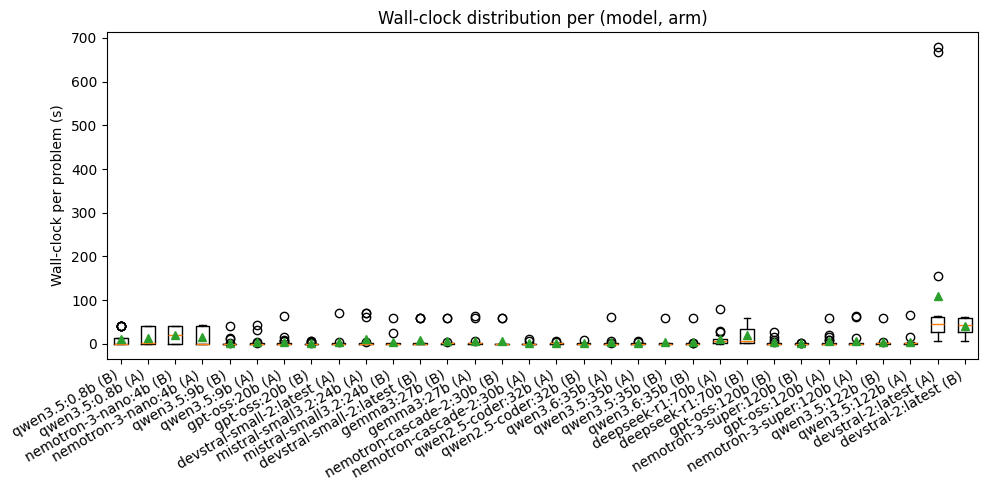

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
df2 = df.copy()
df2['label'] = df2['model'] + ' (' + df2['arm'] + ')'
df2 = df2.sort_values('params_b')
labels_order = df2['label'].unique().tolist()
data = [df2[df2['label']==l]['wall_s'].values for l in labels_order]
ax.boxplot(data, labels=labels_order, showmeans=True)
ax.set_xticklabels(labels_order, rotation=30, ha='right')
ax.set_ylabel('Wall-clock per problem (s)')
ax.set_title('Wall-clock distribution per (model, arm)')
plt.tight_layout(); plt.show()

## Attempts distribution (histogram)

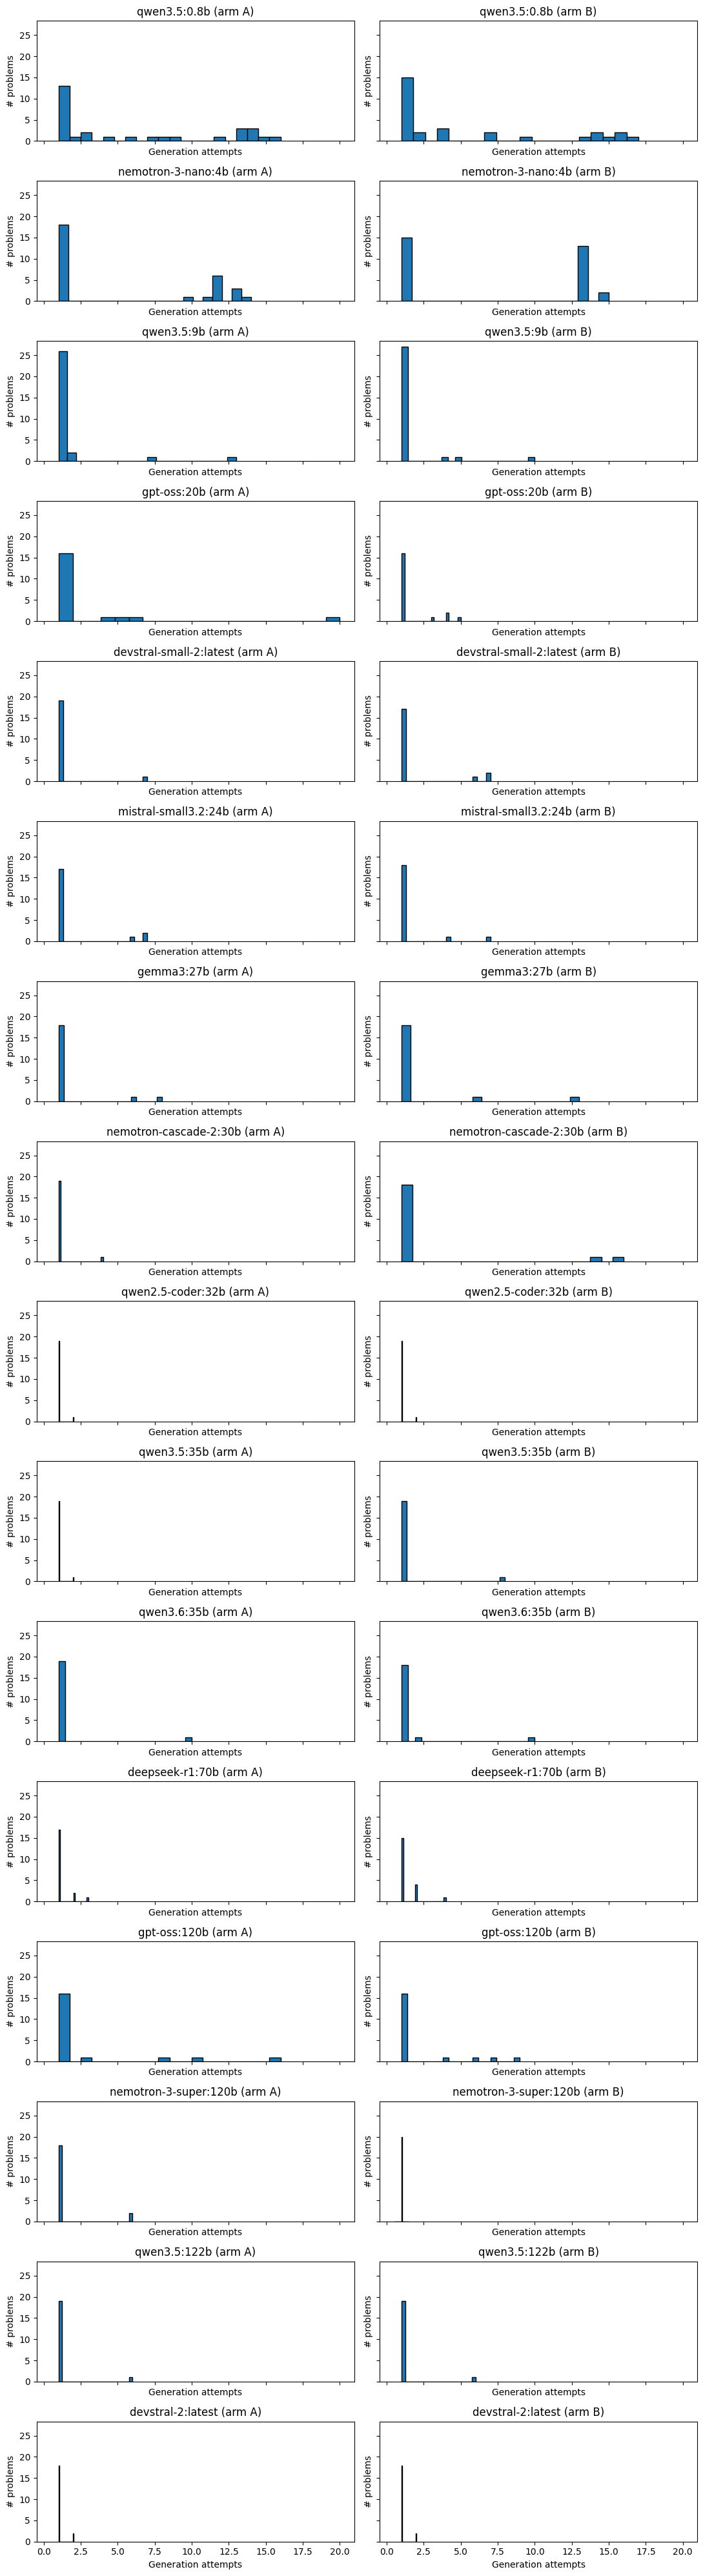

In [12]:
fig, axes = plt.subplots(len(models), 2, figsize=(11, 2.5 * len(models)), sharex=True, sharey=True)
if len(models) == 1:
    axes = axes.reshape(1, 2)
for i, model in enumerate(models):
    for j, arm in enumerate(['A', 'B']):
        sub = df[(df['model'] == model) & (df['arm'] == arm)]
        axes[i, j].hist(sub['attempts'], bins=20, edgecolor='black')
        axes[i, j].set_title(f'{model} (arm {arm})')
        axes[i, j].set_xlabel('Generation attempts')
        axes[i, j].set_ylabel('# problems')
plt.tight_layout(); plt.show()